In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import beta as beta_function
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
NUM_SCENARIOS = 50000
CONFIDENCE_LEVELS = [0.95, 0.99]
np.random.seed(42)
 
# Ratings (ordered from best to worst)
RATINGS = ['Aa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa-C', 'Default']
RATING_INDEX = {rating: i for i, rating in enumerate(RATINGS)}

In [3]:
#Steps 1 & 2: Uncorrelated and Correlated asset returns

In [4]:
def generate_correlated_returns(num_scenarios, cholesky_matrix, num_bonds=3):
    """
    Generate correlated asset returns using Cholesky decomposition.
    
    Args:
        num_scenarios: Number of MC scenarios (50,000)
        cholesky_matrix: 3x3 lower triangular Cholesky matrix
        num_bonds: Number of bonds (3)
    
    Returns:
        correlated_returns: (num_scenarios, num_bonds) array of correlated returns
    """
    # Step 1: Generate uncorrelated standard normal returns
    uncorrelated_returns = np.random.standard_normal((num_scenarios, num_bonds))
    
    # Step 2: Apply Cholesky matrix to induce correlation
    # Formula: correlated = uncorrelated @ cholesky.T
    correlated_returns = uncorrelated_returns @ cholesky_matrix.T
    
    return correlated_returns, uncorrelated_returns
    

In [5]:
#Step 3: Map Returns to Rating Scenarios Using Thresholds

In [6]:
 def map_returns_to_ratings(correlated_returns, rating_thresholds):
    """
    Map correlated asset returns to rating states using proper CreditMetrics thresholds.
    
    rating_thresholds[bond] contains:
        - "thresholds": np.array([...]) sorted ascending
        - "states":     list of rating labels, len = len(thresholds) + 1
    """
    num_scenarios, num_bonds = correlated_returns.shape
    rating_scenarios = {}

    for bond_idx, (bond_name, info) in enumerate(rating_thresholds.items()):
        thresholds = info["thresholds"]      # e.g. [-2.63, -2.23, -1.56, 2.63]
        states     = info["states"]          # e.g. ["D","CCC","B","BB","BBB"]

        z = correlated_returns[:, bond_idx]

        # searchsorted gives the correct interval index
        idx = np.searchsorted(thresholds, z)

        # map indices to rating labels
        mapped = np.array([states[i] for i in idx])

        rating_scenarios[bond_name] = mapped

    return rating_scenarios

In [7]:
#Step 4: Generate Uncorrelated Recovery Rates Using Beta Distribution

In [8]:
 def generate_recovery_rates(num_scenarios, alpha, beta, num_bonds=3):
    """
    Generate uncorrelated recovery rates using Beta distribution.
    Uses Beta(alpha, beta) inverse CDF on uniform(0,1) random variables.
    
    Args:
        num_scenarios: Number of MC scenarios (50,000)
        alpha: Shape parameter (same for all bonds)
        beta: Shape parameter (same for all bonds)
        num_bonds: Number of bonds (3)
    
    Returns:
        recovery_rates: (num_scenarios, num_bonds) array of recovery rates [0,1]
    """
    # Generate uncorrelated uniform(0,1) random variables
    uniform_random = np.random.uniform(0, 1, (num_scenarios, num_bonds))
    
    # Apply inverse beta CDF: betainv(u) = Beta^(-1)(u; alpha, beta)
    # Use scipy's beta distribution PPF (percent point function = inverse CDF)
    from scipy.stats import beta as beta_dist
    recovery_rates = beta_dist.ppf(uniform_random, alpha, beta)
    
    # Clip to [0, 1] to handle numerical edge cases
    recovery_rates = np.clip(recovery_rates, 0, 1)
    
    return recovery_rates, uniform_random

In [9]:
#Step 5: Calcualte Implied Forward Loan Values

In [10]:
def calculate_loan_forward_values(rating_scenarios, recovery_rates, forward_values, exposures):
    """
    Calculate implied forward loan values at 1-year horizon.
    
    Args:
        rating_scenarios: dict[bond_name] = array of rating indices
        recovery_rates: (num_scenarios, num_bonds) array of recovery rates
        forward_values: dict[bond_name][rating] = forward value at that rating
        exposures: dict[bond_name] = current exposure
    
    Returns:
        loan_forward_values: dict[bond_name] = (num_scenarios,) array of values
    """
    num_scenarios = recovery_rates.shape[0]
    bond_names = list(rating_scenarios.keys())
    
    loan_forward_values = {bond_name: np.zeros(num_scenarios) 
                          for bond_name in bond_names}
    
    for bond_idx, bond_name in enumerate(bond_names):
        ratings = rating_scenarios[bond_name]
        recoveries = recovery_rates[:, bond_idx]
        exposure = exposures[bond_name]
        forward_vals = forward_values[bond_name]
        
        for scenario_idx in range(num_scenarios):
            rating = ratings[scenario_idx]
            
            if rating == 'Default':
                # In default: value = exposure × recovery rate
                loan_forward_values[bond_name][scenario_idx] = exposure * recoveries[scenario_idx]
            else:
                # Non-default: value = forward value for that rating
                loan_forward_values[bond_name][scenario_idx] = forward_vals[rating]
    
    return loan_forward_values

In [11]:
#Step 6: Calculate Portfolio Values

In [12]:
def calculate_portfolio_values(loan_forward_values):
    """
    Aggregate loan values to portfolio level.
    
    Args:
        loan_forward_values: dict[bond_name] = (num_scenarios,) array
    
    Returns:
        portfolio_values: (num_scenarios,) array of total portfolio values
    """
    num_scenarios = loan_forward_values[list(loan_forward_values.keys())[0]].shape[0]
    portfolio_values = np.zeros(num_scenarios)
    
    for bond_name, values in loan_forward_values.items():
        portfolio_values += values
    
    return portfolio_values

In [13]:
#Step 7: Calculate Losses and VaR/ES

In [14]:
def calculate_losses(portfolio_values, initial_portfolio_value):
    """
    Calculate portfolio losses (negative of returns).
    Loss = Initial Value - Forward Value
    """
    losses = initial_portfolio_value - portfolio_values
    return losses
 
def calculate_var_and_es(losses, confidence_levels):
    """
    Calculate Absolute VaR and Expected Shortfall.
    
    Args:
        losses: (num_scenarios,) array of portfolio losses
        confidence_levels: list of confidence levels [0.95, 0.99]
    
    Returns:
        results: dict with VaR and ES for each confidence level
    """
    results = {}
    
    for conf in confidence_levels:
        # VaR = loss at the confidence level percentile
        var = np.percentile(losses, conf * 100)
        
        # ES = average loss in tail (losses >= VaR)
        tail_losses = losses[losses >= var]
        es = np.mean(tail_losses) if len(tail_losses) > 0 else var
        
        results[conf] = {
            'VaR': var,
            'ES': es,
            'num_tail': len(tail_losses),
            'pct_tail': (len(tail_losses) / len(losses)) * 100
        }
    
    return results

In [15]:
#Cholesky Calculation

In [16]:
corr = np.array([
    [1, 0.5218658964, 0.4665205594],
    [0.5218658964, 1, 0.4250442945],
    [0.4665205594, 0.4250442945, 1]
])

L = np.linalg.cholesky(corr)

print(corr)
print(L)

[[1.         0.5218659  0.46652056]
 [0.5218659  1.         0.42504429]
 [0.46652056 0.42504429 1.        ]]
[[1.         0.         0.        ]
 [0.5218659  0.85302754 0.        ]
 [0.46652056 0.21286901 0.85851346]]


In [17]:
#Main Execution

In [18]:
def main():
    print("=" * 90)
    print("CREDITMETRICS: CORRELATED MONTE CARLO SIMULATION")
    print("=" * 90)
    
    # Bond names and current information
    bond_names = ['Boyd Gaming Corp', 'Brinker International Inc', 'American Airlines Group Inc']
    
    # Current exposures (in dollars)
    exposures = {
        'Boyd Gaming Corp': 4_000_000,
        'Brinker International Inc': 5_000_000,
        'American Airlines Group Inc': 6_000_000
    }
    
    # Current forward values at t=0 (should be close to exposures) Found in "Valuation" Worksheet
    current_values = {
        'Boyd Gaming Corp': 4_198_521,
        'Brinker International Inc': 5_505_579,
        'American Airlines Group Inc': 7_009_837
    }
    
    initial_portfolio_value = sum(current_values.values())
    
    # Forward values at 1-year horizon for each rating. Found in "Valuation" Worksheet
    forward_values = {
        'Boyd Gaming Corp': {
            'Aaa': 4_345_450,
            'Aa': 4_317_394,
            'A': 4_305_235,
            'Baa': 4_282_173,
            'Ba': 4_218_112,
            'B': 4_130_678,
            'Caa-C': 3_928_288,
            'Default': 0  # Will be overridden by recovery × exposure
        },
        'Brinker International Inc': {
            'Aaa': 5_669_568,
            'Aa': 5_616_557,
            'A': 5_595_895,
            'Baa': 5_551_549,
            'Ba': 5_430_615,
            'B': 5_282_823,
            'Caa-C': 4_919_623,
            'Default': 0
        },
        'American Airlines Group Inc': {
            'Aaa': 7_178_778,
            'Aa': 7_092_932,
            'A': 7_062_203,
            'Baa': 6_989_991,
            'Ba': 6_793_624,
            'B': 6_578_192,
            'Caa-C': 6_014_339,
            'Default': 0
        }
    }
    
    # Cholesky matrix (3x3 lower triangular for 3 bonds)
    cholesky_matrix = np.array([
        [1.0000, 0.0000, 0.0000],
        [0.5219, 0.8530, 0.0000],
        [0.4665, 0.2129, 0.8585]
    ])
    
    # Rating thresholds. Found in "VaR Calculation" Worksheet
    # Structure: thresholds[bond][rating] = threshold value
    rating_thresholds = {
        "Boyd Gaming Corp": {
        "thresholds": np.array([-1.1896,-1.1523,-0.9710,2.6742]),
        "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
        },
        "Brinker International Inc": {
        "thresholds": np.array([-1.1896,-1.1523,-0.9710,2.6742]),
        "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
        },
        "American Airlines Group Inc": {
        "thresholds": np.array([-0.8618,-0.8116,1.0037, 2.4546]),
        "states": ["Default","Caa-C", "B", "Ba", "Baa"]
        }
    }
    
    # Recovery rate distribution parameters (Beta distribution). Found in "Valuation" Worksheet
    # Same alpha and beta for all bonds (Senior Unsecured
    alpha = 8.3653      # Beta alpha parameter
    beta_param = 13.7068 # Beta beta parameter
    
    print(f"\nPortfolio Configuration:")
    print(f"  Bonds: {', '.join(bond_names)}")
    print(f"  Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
    print(f"  Number of Scenarios: {NUM_SCENARIOS:,}")
    print(f"  Recovery Distribution: Beta(α={alpha}, β={beta_param})")
    print(f"  Correlation Structure: Cholesky-induced")

#=========================================================================================================================
    #Step 1 & 2
    print(f"\nStep 1-2: Generating {NUM_SCENARIOS:,} correlated asset return scenarios...")
    correlated_returns, uncorrelated_returns = generate_correlated_returns(
        NUM_SCENARIOS, cholesky_matrix, num_bonds=3
    )
    print(f"  ✓ Uncorrelated returns shape: {uncorrelated_returns.shape}")
    print(f"  ✓ Correlated returns shape: {correlated_returns.shape}")
    print(f"  ✓ Correlation matrix (from data):\n{np.corrcoef(correlated_returns.T)}")

    #Step 3
    print(f"\nStep 3: Mapping returns to rating scenarios using thresholds...")
    rating_scenarios = map_returns_to_ratings(correlated_returns, rating_thresholds)
    
    # Summary of rating distributions
    for bond_name in bond_names:
        ratings = rating_scenarios[bond_name]
        unique, counts = np.unique(ratings, return_counts=True)
        print(f"\n  {bond_name}:")
        for rating_label, count in zip(unique, counts):
            pct = (count / NUM_SCENARIOS) * 100
            print(f"    {rating_label:8s}: {count:>6,} scenarios ({pct:>5.2f}%)")
    
    #Step 4
    print(f"\nStep 4: Generating uncorrelated recovery rates using Beta distribution...")
    recovery_rates, uniform_random = generate_recovery_rates(
        NUM_SCENARIOS, alpha, beta_param, num_bonds=3
    )
    print(f"  ✓ Uniform random values shape: {uniform_random.shape}")
    print(f"  ✓ Recovery rates shape: {recovery_rates.shape}")
    print(f"  ✓ Recovery statistics:")
    print(f"    Mean recovery: {np.mean(recovery_rates):.4f}")
    print(f"    Std recovery:  {np.std(recovery_rates):.4f}")
    print(f"    Min recovery:  {np.min(recovery_rates):.4f}")
    print(f"    Max recovery:  {np.max(recovery_rates):.4f}")

    #Step 5
    print(f"\nStep 5: Calculating implied forward loan values...")
    loan_forward_values = calculate_loan_forward_values(
        rating_scenarios, recovery_rates, forward_values, exposures
    )
    
    for bond_name in bond_names:
        values = loan_forward_values[bond_name]
        print(f"\n  {bond_name}:")
        print(f"    Mean forward value: ${np.mean(values):>15,.2f}")
        print(f"    Std forward value:  ${np.std(values):>15,.2f}")
        print(f"    Min forward value:  ${np.min(values):>15,.2f}")
        print(f"    Max forward value:  ${np.max(values):>15,.2f}")

    #Step 6
    print(f"\nStep 6: Aggregating to portfolio values...")
    portfolio_values = calculate_portfolio_values(loan_forward_values)
    
    print(f"  ✓ Portfolio values shape: {portfolio_values.shape}")
    print(f"  Portfolio value statistics:")
    print(f"    Mean portfolio value: ${np.mean(portfolio_values):>15,.2f}")
    print(f"    Std portfolio value:  ${np.std(portfolio_values):>15,.2f}")
    print(f"    Min portfolio value:  ${np.min(portfolio_values):>15,.2f}")
    print(f"    Max portfolio value:  ${np.max(portfolio_values):>15,.2f}")

    #Step 7
    print(f"\nStep 7: Calculating portfolio losses...")
    losses = calculate_losses(portfolio_values, initial_portfolio_value)
    
    print(f"  Loss statistics:")
    print(f"    Mean loss:    ${np.mean(losses):>15,.2f}")
    print(f"    Median loss:  ${np.median(losses):>15,.2f}")
    print(f"    Std loss:     ${np.std(losses):>15,.2f}")
    print(f"    Min loss:     ${np.min(losses):>15,.2f}")
    print(f"    Max loss:     ${np.max(losses):>15,.2f}")

    #Step 8
    print(f"\nStep 8: Calculating Absolute VaR and Expected Shortfall...")
    results = calculate_var_and_es(losses, CONFIDENCE_LEVELS)
    
    print("\n" + "=" * 90)
    print("FINAL RESULTS: ABSOLUTE VaR & EXPECTED SHORTFALL")
    print("=" * 90)
    
    for conf in sorted(CONFIDENCE_LEVELS):
        conf_pct = int(conf * 100)
        var = results[conf]['VaR']
        es = results[conf]['ES']
        
        print(f"\nConfidence Level: {conf_pct}%")
        print(f"  Absolute VaR:              ${var:>15,.2f}")
        print(f"  Absolute Expected Shortfall: ${es:>15,.2f}")
        print(f"  Tail Observations:         {results[conf]['num_tail']:>15,} ({results[conf]['pct_tail']:.2f}%)")

    print(f"\nGenerating visualizations...")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('CreditMetrics: Correlated Returns with Variable Recovery (2.4A)', 
                 fontsize=16, fontweight='bold')

#========================================================================================================================    
    # Plot 1: Loss distribution
    ax = axes[0, 0]
    ax.hist(losses, bins=150, color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(results[0.95]['VaR'], color='red', linestyle='--', linewidth=2.5, 
               label=f"VaR95: ${results[0.95]['VaR']:,.0f}")
    ax.axvline(results[0.99]['VaR'], color='darkred', linestyle='--', linewidth=2.5,
               label=f"VaR99: ${results[0.99]['VaR']:,.0f}")
    ax.set_xlabel('Portfolio Loss ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Portfolio Loss Distribution (50K Scenarios) (2.4A)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    
    # Plot 2: Tail losses
    ax = axes[0, 1]
    tail_losses = losses[losses > results[0.95]['VaR']]
    ax.hist(tail_losses, bins=60, color='#A23B72', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(results[0.95]['VaR'], color='red', linestyle='--', linewidth=2.5,
               label=f"VaR95: ${results[0.95]['VaR']:,.0f}")
    ax.axvline(results[0.95]['ES'], color='orange', linestyle='--', linewidth=2.5,
               label=f"ES95: ${results[0.95]['ES']:,.0f}")
    ax.set_xlabel('Portfolio Loss ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Tail Risk (Worst 5%) (2.4A)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    
    # Plot 3: VaR vs ES
    ax = axes[1, 0]
    conf_labels = ['95%', '99%']
    var_vals = [results[0.95]['VaR'], results[0.99]['VaR']]
    es_vals = [results[0.95]['ES'], results[0.99]['ES']]
    
    x = np.arange(len(conf_labels))
    width = 0.35
    bars1 = ax.bar(x - width/2, var_vals, width, label='VaR', color='#F18F01', 
                   alpha=0.85, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, es_vals, width, label='ES', color='#C73E1D',
                   alpha=0.85, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Loss Amount ($)', fontsize=11, fontweight='bold')
    ax.set_title('Absolute VaR vs Expected Shortfall (2.4A)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(conf_labels)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'${height/1e6:.2f}M', ha='center', va='bottom', 
                   fontsize=9, fontweight='bold')
    
    # Plot 4: CDF with percentiles
    ax = axes[1, 1]
    sorted_losses = np.sort(losses)
    cdf = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)
    ax.plot(sorted_losses, cdf * 100, linewidth=2.5, color='#2E86AB', label='Empirical CDF')
    ax.axvline(results[0.95]['VaR'], color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label='VaR95')
    ax.axhline(95, color='red', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.axvline(results[0.99]['VaR'], color='darkred', linestyle='--', linewidth=2,
               alpha=0.7, label='VaR99')
    ax.axhline(99, color='darkred', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Portfolio Loss ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative Probability (%)', fontsize=11, fontweight='bold')
    ax.set_title('Empirical CDF of Losses (2.4A)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    
    plt.tight_layout()
    plt.savefig('creditmetrics_correlated_2.4A.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: creditmetrics_correlated_2.4A.png")
    plt.show()

#=========================================================================================================================
    # EXPORT RESULTS
    print("\nBuilding comprehensive Excel export...")

    rating_names = np.column_stack([
    rating_scenarios['Boyd Gaming Corp'],
    rating_scenarios['Brinker International Inc'],
    rating_scenarios['American Airlines Group Inc'],
])
    
    data_dict = {
        'Scenario': np.arange(1, NUM_SCENARIOS + 1),
        
        # Uncorrelated asset returns
        'Uncorr_Return_Boyd': uncorrelated_returns[:, 0],
        'Uncorr_Return_Brinker': uncorrelated_returns[:, 1],
        'Uncorr_Return_American': uncorrelated_returns[:, 2],
        
        # Correlated asset returns
        'Corr_Return_Boyd': correlated_returns[:, 0],
        'Corr_Return_Brinker': correlated_returns[:, 1],
        'Corr_Return_American': correlated_returns[:, 2],
        
        # Rating scenarios
        'Rating_Boyd': rating_names[:, 0],
        'Rating_Brinker': rating_names[:, 1],
        'Rating_American': rating_names[:, 2],
        
        # Uniform random for recovery
        'Uniform_Boyd': uniform_random[:, 0],
        'Uniform_Brinker': uniform_random[:, 1],
        'Uniform_American': uniform_random[:, 2],
        
        # Recovery rates
        'Recovery_Boyd': recovery_rates[:, 0],
        'Recovery_Brinker': recovery_rates[:, 1],
        'Recovery_American': recovery_rates[:, 2],
        
        # Implied forward loan values
        'Value_Boyd': loan_forward_values['Boyd Gaming Corp'],
        'Value_Brinker': loan_forward_values['Brinker International Inc'],
        'Value_American': loan_forward_values['American Airlines Group Inc'],

        # Portfolio level
        'Portfolio_Value': portfolio_values,
        'Loss': losses
    }
    
    df_scenarios = pd.DataFrame(data_dict)
    
    # CREATE SUMMARY STATISTICS SHEET
    summary_data = {
        'Metric': [
            'Initial Portfolio Value',
            'Mean Portfolio Value',
            'Std Dev Portfolio Value',
            'Min Portfolio Value',
            'Max Portfolio Value',
            '',
            'Mean Loss',
            'Median Loss',
            'Std Dev Loss',
            'Min Loss',
            'Max Loss',
            '',
            'VaR 95%',
            'ES 95%',
            'Tail Scenarios 95%',
            '',
            'VaR 99%',
            'ES 99%',
            'Tail Scenarios 99%',
        ],
        'Value': [
            initial_portfolio_value,
            np.mean(portfolio_values),
            np.std(portfolio_values),
            np.min(portfolio_values),
            np.max(portfolio_values),
            '',
            np.mean(losses),
            np.median(losses),
            np.std(losses),
            np.min(losses),
            np.max(losses),
            '',
            results[0.95]['VaR'],
            results[0.95]['ES'],
            results[0.95]['num_tail'],
            '',
            results[0.99]['VaR'],
            results[0.99]['ES'],
            results[0.99]['num_tail']
        ]
    }
    
    df_summary = pd.DataFrame(summary_data)
    
    # CREATE RATING DISTRIBUTION SHEET
    rating_dist_data = []
    for bond_idx, bond_name in enumerate(bond_names):
        states = rating_thresholds[bond_name]['states']
        for rating in states:
            count = np.sum(rating_names[:, bond_idx] == rating)
            pct = (count / NUM_SCENARIOS) * 100
            rating_dist_data.append({
                'Bond': bond_name,
                'Rating': rating,
                'Count': count,
                'Percentage': f"{pct:.2f}%"
            })

    
    df_rating_dist = pd.DataFrame(rating_dist_data)

    # CREATE LOSS PERCENTILES SHEET
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    loss_percentiles = []
    for p in percentiles:
        loss_percentiles.append({
            'Percentile': f"{p}%",
            'Loss': np.percentile(losses, p)
        })
    
    df_percentiles = pd.DataFrame(loss_percentiles)
    
    print("\nExporting to Excel...")
    with pd.ExcelWriter('creditmetrics_full_simulation_2.4A.xlsx', engine='openpyxl') as writer:
        df_scenarios.to_excel(writer, sheet_name='All Scenarios', index=False)
        df_summary.to_excel(writer, sheet_name='Summary', index=False)
        df_rating_dist.to_excel(writer, sheet_name='Rating Distribution', index=False)
        df_percentiles.to_excel(writer, sheet_name='Loss Percentiles', index=False)
    
    print("✓ Saved: creditmetrics_full_simulation_2.4A.xlsx")
    
    print("\n" + "=" * 90)
    print("SIMULATION COMPLETE")
    print("=" * 90)

CREDITMETRICS: CORRELATED MONTE CARLO SIMULATION

Portfolio Configuration:
  Bonds: Boyd Gaming Corp, Brinker International Inc, American Airlines Group Inc
  Initial Portfolio Value: $16,713,937.00
  Number of Scenarios: 50,000
  Recovery Distribution: Beta(α=8.3653, β=13.7068)
  Correlation Structure: Cholesky-induced

Step 1-2: Generating 50,000 correlated asset return scenarios...
  ✓ Uncorrelated returns shape: (50000, 3)
  ✓ Correlated returns shape: (50000, 3)
  ✓ Correlation matrix (from data):
[[1.         0.525958   0.46465949]
 [0.525958   1.         0.4288979 ]
 [0.46465949 0.4288979  1.        ]]

Step 3: Mapping returns to rating scenarios using thresholds...

  Boyd Gaming Corp:
    B       :  2,060 scenarios ( 4.12%)
    Ba      : 41,472 scenarios (82.94%)
    Baa     :    180 scenarios ( 0.36%)
    Caa-C   :    358 scenarios ( 0.72%)
    Default :  5,930 scenarios (11.86%)

  Brinker International Inc:
    B       :  2,040 scenarios ( 4.08%)
    Ba      : 41,515 scenar

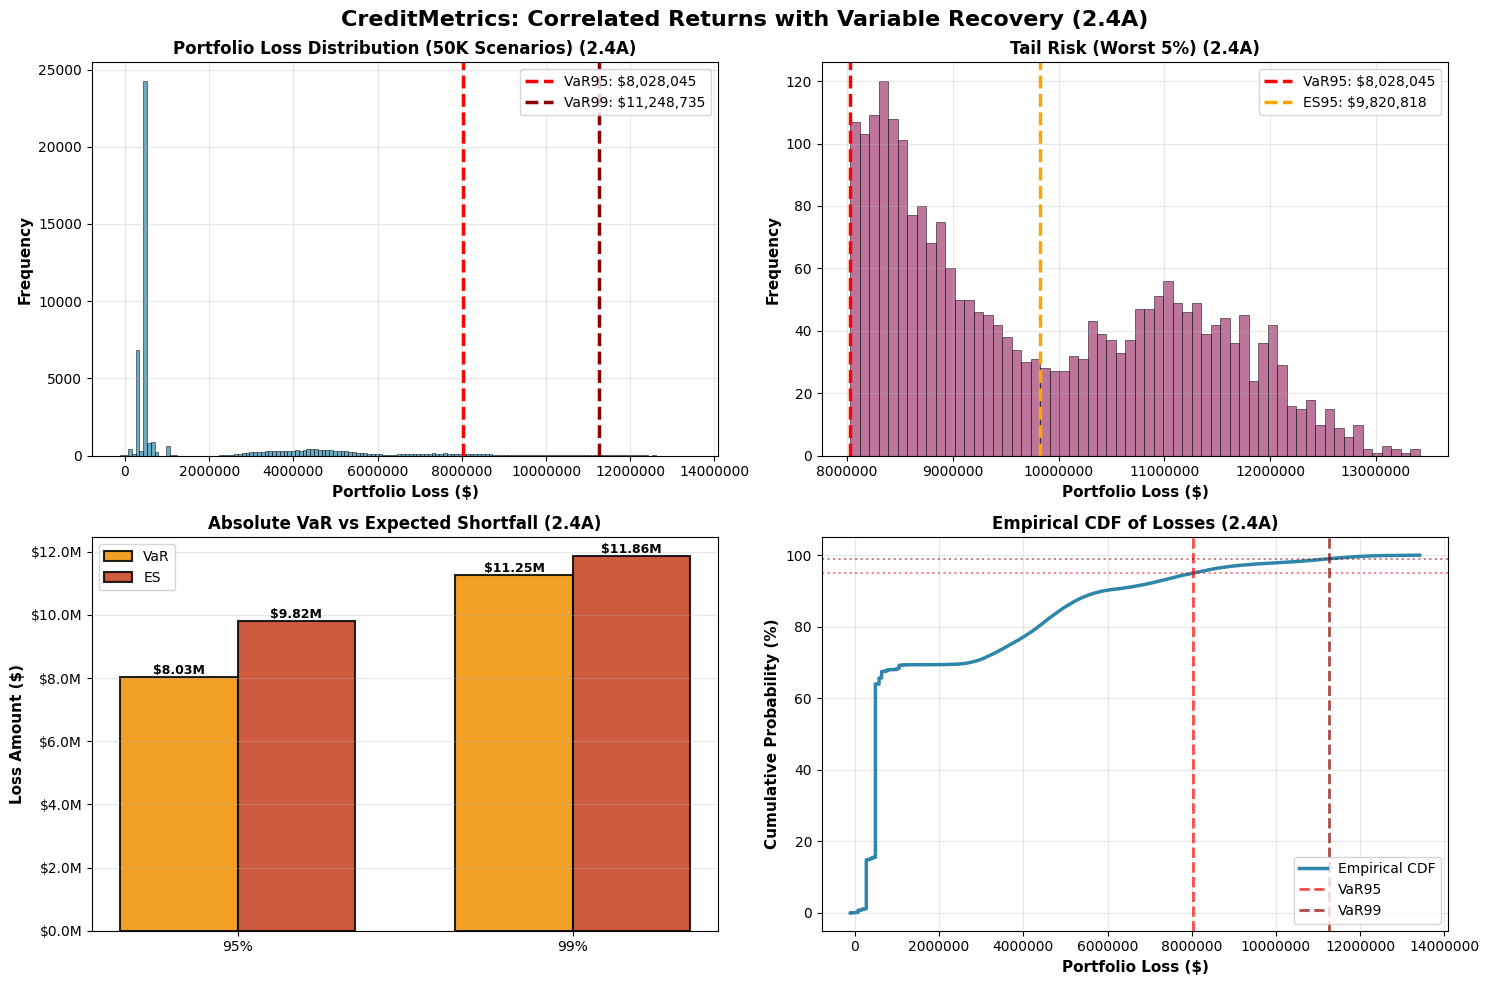


Building comprehensive Excel export...

Exporting to Excel...
✓ Saved: creditmetrics_full_simulation_2.4A.xlsx

SIMULATION COMPLETE


In [19]:
if __name__ == '__main__':
    main()